# Data

In [51]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src import config as c, data, sql

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.figsize": (10, 3), "axes.grid": True, "grid.alpha": .3})

In [52]:
us = data.dataset("us")
china = data.dataset("china")

In [53]:
us.shape, china.shape

((288, 12), (264, 11))

In [54]:
us.head()

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other,inc,ind,rpk,vmt,rpo_real
month,,,,,,,,,,,,
2002-01-01,"1,805.71",NaN,"8,309.10","1,696.48","4,018.58",799.03,NaN,"10,298.90",87.93,"44,271,037.00","241,050.00",0.11
2002-02-01,"1,766.96",NaN,"8,685.93","1,643.04","3,788.21",747.61,NaN,"10,514.70",88.52,"45,245,063.00","230,511.00",0.11
2002-03-01,"1,524.48",NaN,"8,761.94","1,683.29","3,852.65",940.87,NaN,"10,531.60",88.53,"48,167,518.00","229,584.00",0.12
2002-04-01,"1,273.43",NaN,"8,838.67","1,720.40","3,883.47",801.67,NaN,"10,539.00",89.17,"46,587,854.00","215,215.00",0.13
2002-05-01,"1,331.16",NaN,"9,170.87","1,613.87","3,766.00",783.10,NaN,"10,574.20",89.60,"45,157,584.00","208,237.00",0.14


In [55]:
us.dtypes

d1_lpg         float64
d2_naphtha     float64
d3_gasoline    float64
d4_jetkero     float64
d5_gasoil      float64
d6_fueloil     float64
d7_other       float64
inc            float64
ind            float64
rpk            float64
vmt            float64
rpo_real       float64
dtype: object

In [56]:
us.index.min(), us.index.max(), pd.infer_freq(us.index)

(Timestamp('2002-01-01 00:00:00'), Timestamp('2025-12-01 00:00:00'), 'MS')

In [57]:
china.tail(3)

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other,inv,lkq_credit,lkq_electricity,wtr
month,,,,,,,,,,,
2025-10-01,"2,769.23","2,410.57","3,484.18",869.99,"3,960.87",856.62,"2,109.81","7,514.54","274,959.39","10,069.88",109.66
2025-11-01,"2,717.34","2,537.23","3,358.07",589.38,"4,055.07",893.10,"3,372.01","7,514.54","274,959.39","10,069.88",111.04
2025-12-01,"2,806.98","2,464.68","3,365.18",569.36,"4,030.84",794.09,"4,094.33","7,582.05","277,453.00","10,069.88",110.20


## SQL

In [58]:
sql.query("SELECT COUNT(*) FROM demand")

,count_star()
0,3648


In [59]:
sql.query("SELECT COUNT(*) FROM predictors")

,count_star()
0,5037


In [60]:
sql.query("""
    SELECT region, product, MIN(month), MAX(month), COUNT(*)
    FROM demand GROUP BY 1, 2 ORDER BY 1, 2
""")

,region,product,"min(""month"")","max(""month"")",count_star()
0,china,d1_lpg,2004-01-01,2026-06-01,270
1,china,d2_naphtha,2010-01-01,2026-06-01,198
2,china,d3_gasoline,2004-01-01,2026-06-01,270
3,china,d4_jetkero,2004-01-01,2026-06-01,270
4,china,d5_gasoil,2004-01-01,2026-06-01,270
5,china,d6_fueloil,2004-01-01,2026-06-01,270
6,china,d7_other,2009-01-01,2026-06-01,210
7,us,d1_lpg,2002-01-01,2026-06-01,294
8,us,d2_naphtha,2009-01-01,2026-06-01,210
9,us,d3_gasoline,2002-01-01,2026-06-01,294


In [61]:
sql.query("""
    SELECT region, variable, MIN(period_end), MAX(period_end), COUNT(*)
    FROM predictors GROUP BY 1, 2 ORDER BY 1, 2
""")

,region,variable,min(period_end),max(period_end),count_star()
0,china,inv,1960-12-31,2024-12-31,65
1,china,lkq_credit,1985-12-31,2025-12-31,161
2,china,lkq_electricity,2000-12-31,2025-12-31,26
3,china,wtr,2000-01-31,2026-06-30,318
4,us,brent,1992-01-31,2026-07-31,415
5,us,cpi,1947-01-31,2026-07-31,954
6,us,inc,1959-01-31,2026-07-31,811
7,us,ind,1919-01-31,2026-07-31,1291
8,us,rpk,2000-01-31,2026-05-31,317
9,us,vmt,1970-01-31,2026-07-31,679


In [62]:
sql.query("""
    SELECT region, product, month, COUNT(*)
    FROM demand GROUP BY 1, 2, 3 HAVING COUNT(*) > 1
""")

,region,product,month,count_star()


In [63]:
sql.query("""
    SELECT region, variable, period_end, COUNT(*)
    FROM predictors GROUP BY 1, 2, 3 HAVING COUNT(*) > 1
""")

,region,variable,period_end,count_star()


In [64]:
sql.query("SELECT * FROM demand WHERE kbd <= 0")

,region,product,month,kbd
0,us,d2_naphtha,2026-06-01,0.00


In [65]:
# US 2019 against the paper's Table 3 (IEA MODS), kb/d
paper = pd.Series({"d1_lpg": 2638, "d2_naphtha": 207, "d3_gasoline": 9296, "d4_jetkero": 1760,
                   "d5_gasoil": 4112, "d6_fueloil": 306, "d7_other": 2260})
jodi = sql.query("""
    SELECT product, AVG(kbd) AS kbd
    FROM demand WHERE region = 'us' AND YEAR(month) = 2019 GROUP BY 1 ORDER BY 1
""").set_index("product")["kbd"]
pd.DataFrame({"paper": paper, "jodi": jodi.round(0), "diff %": (100 * (jodi / paper - 1)).round(1)})

,paper,jodi,diff %
d1_lpg,2638,"1,109.00",-58.00
d2_naphtha,207,207.00,0.10
d3_gasoline,9296,"9,344.00",0.50
d4_jetkero,1760,"1,764.00",0.20
d5_gasoil,4112,"4,133.00",0.50
d6_fueloil,306,308.00,0.60
d7_other,2260,"3,536.00",56.50


In [66]:
# lpg and other differ by definition, not by error: JODI books ethane in other products, the paper in LPG
paper[["d1_lpg", "d7_other"]].sum(), jodi[["d1_lpg", "d7_other"]].sum().round(0)

(np.int64(4898), np.float64(4645.0))

## Cleaning

In [67]:
us.isna().sum()

d1_lpg          0
d2_naphtha     84
d3_gasoline     0
d4_jetkero      0
d5_gasoil       0
d6_fueloil      0
d7_other       84
inc             0
ind             0
rpk             0
vmt             0
rpo_real        0
dtype: int64

In [68]:
china.isna().sum()

d1_lpg              0
d2_naphtha         72
d3_gasoline         0
d4_jetkero          0
d5_gasoil           0
d6_fueloil          0
d7_other           60
inv                 0
lkq_credit          0
lkq_electricity     0
wtr                 0
dtype: int64

In [69]:
us.isna().mean().round(2)

d1_lpg        0.00
d2_naphtha    0.29
d3_gasoline   0.00
d4_jetkero    0.00
d5_gasoil     0.00
d6_fueloil    0.00
d7_other      0.29
inc           0.00
ind           0.00
rpk           0.00
vmt           0.00
rpo_real      0.00
dtype: float64

In [70]:
# leading NaN only: JODI reports naphtha and other products from 2009. Left missing, a tree handles it
us.apply(lambda s: s.first_valid_index())

d1_lpg        2002-01-01
d2_naphtha    2009-01-01
d3_gasoline   2002-01-01
d4_jetkero    2002-01-01
d5_gasoil     2002-01-01
d6_fueloil    2002-01-01
d7_other      2009-01-01
inc           2002-01-01
ind           2002-01-01
rpk           2002-01-01
vmt           2002-01-01
rpo_real      2002-01-01
dtype: datetime64[us]

In [71]:
(us[c.PRODUCTS] <= 0).sum()

d1_lpg         0
d2_naphtha     0
d3_gasoline    0
d4_jetkero     0
d5_gasoil      0
d6_fueloil     0
d7_other       0
dtype: int64

In [72]:
# largest month-on-month moves in %: real volatility or a reporting accident?
us[c.PRODUCTS].pct_change().abs().mul(100).stack().nlargest(5).round(0)

month                 
2020-06-01  d6_fueloil   136.00
2016-03-01  d6_fueloil    87.00
2021-05-01  d6_fueloil    81.00
2014-01-01  d6_fueloil    78.00
2017-01-01  d6_fueloil    71.00
dtype: float64

## Time series

In [73]:
raw = sql.query("SELECT variable, period_end, value FROM predictors WHERE region = 'china' ORDER BY 1, 2")
raw["period_end"] = pd.to_datetime(raw["period_end"])
raw.head()

,variable,period_end,value
0,inv,1960-12-31,23.64
1,inv,1961-12-31,11.42
2,inv,1962-12-31,7.43
3,inv,1963-12-31,11.03
4,inv,1964-12-31,14.54


In [74]:
# days between observations: monthly, quarterly, annual
raw.groupby("variable")["period_end"].apply(lambda s: s.diff().dt.days.median())

variable
inv               365.00
lkq_credit         91.50
lkq_electricity   365.00
wtr                31.00
Name: period_end, dtype: float64

In [75]:
c.LAG

{'demand': 2,
 'inc': 1,
 'vmt': 3,
 'ind': 1,
 'rpk': 3,
 'rpo_real': 1,
 'lkq_electricity': 5,
 'lkq_credit': 6,
 'inv': 12,
 'wtr': 2}

In [76]:
# publication date: the end of the period described, plus the source's lag
raw["available_at"] = [end + pd.offsets.MonthEnd(c.LAG[name])
                       for end, name in zip(raw["period_end"], raw["variable"])]
raw[raw["variable"] == "lkq_credit"].tail(4)

,variable,period_end,value,available_at
222,lkq_credit,2025-03-31,"274,959.39",2025-09-30
223,lkq_credit,2025-06-30,"277,453.00",2025-12-31
224,lkq_credit,2025-09-30,"279,597.03",2026-03-31
225,lkq_credit,2025-12-31,"281,351.57",2026-06-30


In [77]:
(raw["available_at"] > raw["period_end"]).all()

np.True_

In [78]:
# for each month end, the latest value already published
credit = raw[raw["variable"] == "lkq_credit"][["available_at", "value"]].rename(columns={"value": "lkq_credit"})
months = pd.DataFrame({"month_end": pd.date_range("2023-06-30", "2024-06-30", freq="ME")})
aligned = pd.merge_asof(months, credit, left_on="month_end", right_on="available_at", direction="backward")
aligned

,month_end,available_at,lkq_credit
0,2023-06-30,2023-06-30,"231,124.89"
1,2023-07-31,2023-06-30,"231,124.89"
2,2023-08-31,2023-06-30,"231,124.89"
3,2023-09-30,2023-09-30,"241,353.75"
4,2023-10-31,2023-09-30,"241,353.75"
5,2023-11-30,2023-09-30,"241,353.75"
6,2023-12-31,2023-12-31,"245,081.23"
7,2024-01-31,2023-12-31,"245,081.23"
8,2024-02-29,2023-12-31,"245,081.23"
9,2024-03-31,2024-03-31,"248,326.24"


In [79]:
# the same step function data.dataset carries
(china.loc["2023-06":"2024-06", "lkq_credit"].to_numpy() == aligned["lkq_credit"].to_numpy()).all()

np.True_

In [80]:
origin = pd.Timestamp(c.ORIGIN) + pd.offsets.MonthEnd(0)  # forecast origin: the last day of December 2023
origin

Timestamp('2023-12-31 00:00:00')

In [81]:
# the information set at the origin: the newest observation of each driver published by then
latest = raw[raw["available_at"] <= origin].groupby("variable").last()
latest

,period_end,value,available_at
variable,,,
inv,2022-12-31,"7,758.15",2023-12-31
lkq_credit,2023-06-30,"245,081.23",2023-12-31
lkq_electricity,2022-12-31,"8,835.76",2023-05-31
wtr,2023-10-31,103.52,2023-12-31


In [82]:
china.loc[c.ORIGIN, latest.index]  # the dataset row at the origin

variable
inv                 7,758.15
lkq_credit        245,081.23
lkq_electricity     8,835.76
wtr                   103.52
Name: 2023-12-01 00:00:00, dtype: float64

In [83]:
(china.loc[c.ORIGIN, latest.index] == latest["value"]).all()

np.True_

In [84]:
# demand itself is published two months late: at the origin the newest print is October
pd.DataFrame({"demand": china["d3_gasoline"],
              "lag2": china["d3_gasoline"].shift(c.LAG["demand"])}).loc["2023-10":"2023-12"]

,demand,lag2
month,,
2023-10-01,"3,651.44","3,648.97"
2023-11-01,"3,343.90","3,722.43"
2023-12-01,"3,343.52","3,651.44"


## Transformation

In [85]:
# Brent deflated by the CPI
prices = sql.query("SELECT period_end, variable, value FROM predictors WHERE variable IN ('brent', 'cpi')")
prices = prices.pivot(index="period_end", columns="variable", values="value").dropna()
prices["rpo_real"] = prices["brent"] / prices["cpi"]
prices.tail(3)

variable,brent,cpi,rpo_real
period_end,,,
2026-05-31,103.84,333.98,0.31
2026-06-30,84.49,332.57,0.25
2026-07-31,83.73,332.81,0.25


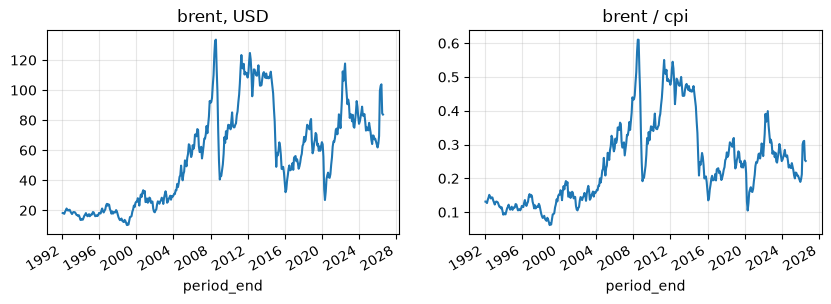

In [86]:
fig, axes = plt.subplots(1, 2)
prices["brent"].plot(ax=axes[0], title="brent, USD")
prices["rpo_real"].plot(ax=axes[1], title="brent / cpi");

In [87]:
# quarterly and annual drivers enter the monthly grid as steps, never interpolated
china.loc["2024", ["wtr", "lkq_credit", "lkq_electricity", "inv"]]

,wtr,lkq_credit,lkq_electricity,inv
month,,,,
2024-01-01,102.41,"245,081.23","8,835.76","7,758.15"
2024-02-01,103.38,"245,081.23","8,835.76","7,758.15"
2024-03-01,102.97,"248,326.24","8,835.76","7,758.15"
2024-04-01,104.61,"248,326.24","8,835.76","7,758.15"
2024-05-01,103.11,"248,326.24","9,439.37","7,758.15"
2024-06-01,104.41,"249,837.46","9,439.37","7,758.15"
2024-07-01,104.43,"249,837.46","9,439.37","7,758.15"
2024-08-01,105.10,"249,837.46","9,439.37","7,758.15"
2024-09-01,104.94,"258,959.59","9,439.37","7,758.15"


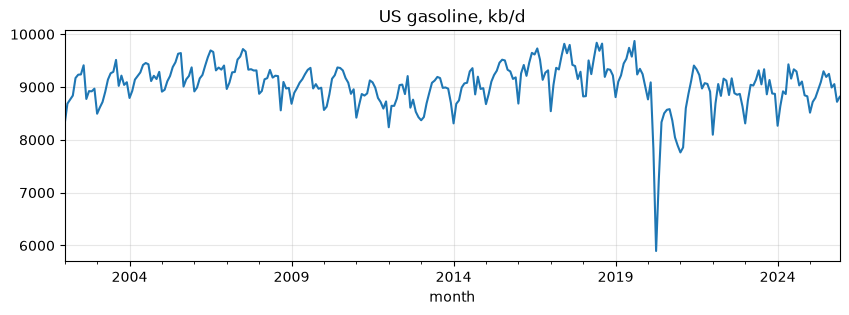

In [88]:
us["d3_gasoline"].plot(title="US gasoline, kb/d");

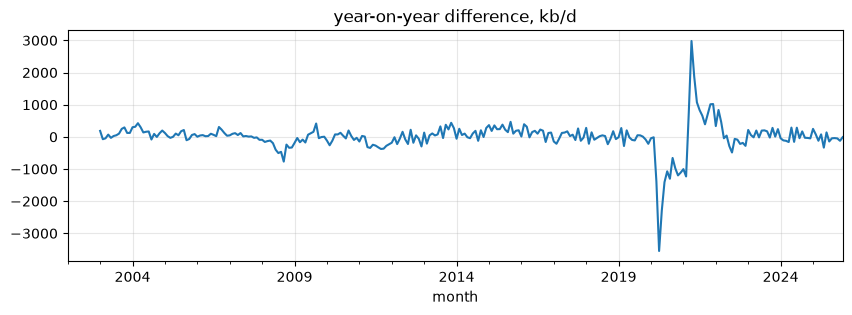

In [89]:
us["d3_gasoline"].diff(12).plot(title="year-on-year difference, kb/d");

In [90]:
history = us.loc[:c.ORIGIN, c.PRODUCTS]  # training sample only
pd.DataFrame({"level acf1": history.apply(lambda s: s.autocorr(1)),
              "level acf12": history.apply(lambda s: s.autocorr(12)),
              "diff12 acf1": history.diff(12).apply(lambda s: s.autocorr(1)),
              "diff12 acf12": history.diff(12).apply(lambda s: s.autocorr(12))}).round(2)

,level acf1,level acf12,diff12 acf1,diff12 acf12
d1_lpg,0.82,0.86,0.48,-0.35
d2_naphtha,0.82,0.65,0.52,-0.45
d3_gasoline,0.75,0.39,0.74,-0.43
d4_jetkero,0.90,0.33,0.88,-0.32
d5_gasoil,0.67,0.51,0.60,-0.15
d6_fueloil,0.93,0.87,0.49,-0.27
d7_other,0.87,0.75,0.48,-0.46


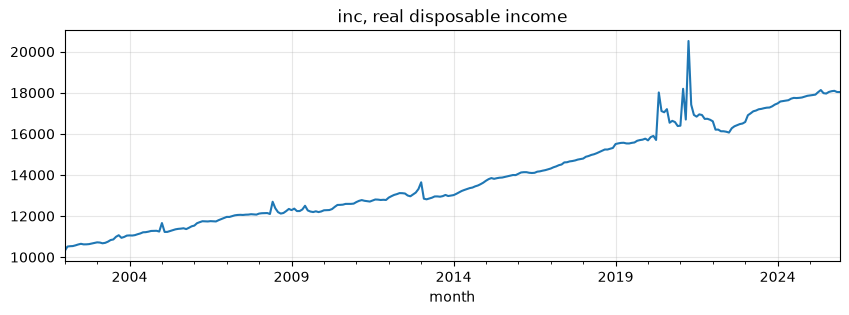

In [91]:
us["inc"].plot(title="inc, real disposable income");

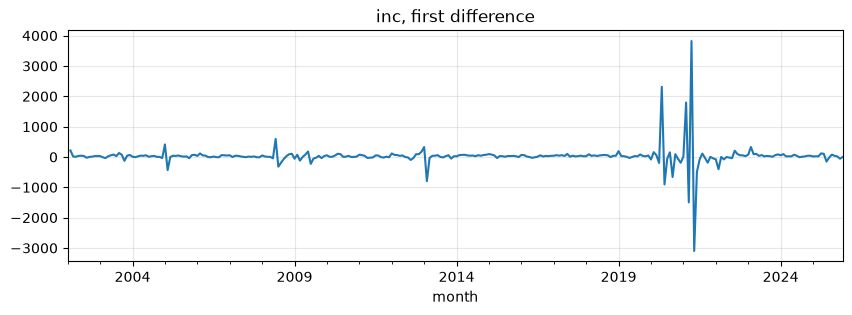

In [92]:
us["inc"].diff().plot(title="inc, first difference");

In [93]:
# levels are kept: the twelve lags carry the seasonality and the score is in kb/d.
# the cost is that a tree cannot forecast a level it has never seen
train, test = us.loc[:c.ORIGIN, c.PRODUCTS], us.loc["2024", c.PRODUCTS]
pd.DataFrame({"train max": train.max(), "2024 max": test.max(), "months above": (test > train.max()).sum()}).round(0)

,train max,2024 max,months above
d1_lpg,"1,884.00","1,550.00",0
d2_naphtha,304.00,180.00,0
d3_gasoline,"9,872.00","9,429.00",0
d4_jetkero,"1,881.00","1,847.00",0
d5_gasoil,"4,651.00","4,417.00",0
d6_fueloil,"1,157.00",350.00,0
d7_other,"4,302.00","4,338.00",1


In [94]:
train, test = china.loc[:c.ORIGIN, c.PRODUCTS], china.loc["2024", c.PRODUCTS]
pd.DataFrame({"train max": train.max(), "2024 max": test.max(), "months above": (test > train.max()).sum()}).round(0)

,train max,2024 max,months above
d1_lpg,"2,877.00","2,994.00",3
d2_naphtha,"2,319.00","2,280.00",0
d3_gasoline,"3,722.00","3,783.00",1
d4_jetkero,989.00,888.00,0
d5_gasoil,"4,275.00","4,115.00",0
d6_fueloil,"1,442.00","1,257.00",0
d7_other,"6,457.00","2,849.00",0


In [95]:
drivers = us.columns.drop(c.PRODUCTS)
train = us.loc[:c.ORIGIN, drivers]
train.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
inc,264.00,"13,518.93","2,036.29","10,298.90","12,058.25","12,986.75","15,073.18","20,520.00"
ind,264.00,97.43,4.68,84.56,93.79,98.87,101.02,104.10
rpk,264.00,"68,914,169.42","15,522,270.43","3,086,801.00","61,862,734.50","69,398,977.50","78,492,964.25","104,221,564.00"
vmt,264.00,"253,586.70","19,710.16","167,617.00","240,690.25","256,393.50","265,654.75","293,308.00"
rpo_real,264.00,0.30,0.12,0.10,0.21,0.28,0.37,0.61


In [96]:
# standardised on the training sample only. Not used: a tree splits on thresholds, notebook 02 checks it
scaled = (us[drivers] - train.mean()) / train.std()
scaled.loc[:c.ORIGIN].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
inc,264.00,-0.00,1.00,-1.58,-0.72,-0.26,0.76,3.44
ind,264.00,0.00,1.00,-2.75,-0.78,0.31,0.77,1.43
rpk,264.00,0.00,1.00,-4.24,-0.45,0.03,0.62,2.27
vmt,264.00,0.00,1.00,-4.36,-0.65,0.14,0.61,2.02
rpo_real,264.00,-0.00,1.00,-1.70,-0.78,-0.21,0.58,2.68


## Final check

In [97]:
us.shape, china.shape

((288, 12), (264, 11))

In [98]:
us.index.min(), us.index.max(), china.index.min(), china.index.max()

(Timestamp('2002-01-01 00:00:00'),
 Timestamp('2025-12-01 00:00:00'),
 Timestamp('2004-01-01 00:00:00'),
 Timestamp('2025-12-01 00:00:00'))

In [99]:
us.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
d1_lpg,288.00,"1,157.60",277.00,628.40,922.00,"1,156.20","1,347.90","1,884.00"
d2_naphtha,204.00,208.30,48.00,107.50,168.40,219.20,242.20,304.10
d3_gasoline,288.00,"9,042.00",422.70,"5,895.80","8,858.40","9,092.40","9,300.70","9,871.70"
d4_jetkero,288.00,"1,595.70",187.20,617.10,"1,484.10","1,635.60","1,720.90","1,880.50"
d5_gasoil,288.00,"4,036.70",227.00,"3,449.90","3,898.80","4,047.00","4,207.00","4,651.20"
d6_fueloil,288.00,515.30,246.80,106.90,328.60,402.80,727.20,"1,157.50"
d7_other,204.00,"3,486.00",450.40,"2,536.30","3,157.40","3,447.90","3,847.40","4,666.10"
inc,288.00,"13,879.70","2,289.00","10,298.90","12,098.00","13,145.00","15,706.20","20,520.00"
ind,288.00,97.70,4.60,84.60,94.70,99.20,101.00,104.10
rpk,288.00,"71,038,080.00","16,655,521.60","3,086,801.00","62,932,088.00","71,314,461.00","80,817,864.20","110,272,196.00"


In [100]:
china.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
d1_lpg,264.00,"1,398.30",778.60,468.50,692.70,"1,135.70","2,052.60","2,993.60"
d2_naphtha,192.00,"1,120.00",595.00,522.20,669.30,818.40,"1,394.40","2,537.20"
d3_gasoline,264.00,"2,347.10",829.30,937.70,"1,492.10","2,447.90","3,027.40","3,782.80"
d4_jetkero,264.00,499.20,232.70,116.60,274.40,448.80,710.00,989.20
d5_gasoil,264.00,"3,023.50",623.10,"1,561.20","2,523.00","3,052.10","3,477.60","4,275.00"
d6_fueloil,264.00,717.90,215.30,293.20,552.20,690.50,852.10,"1,441.70"
d7_other,204.00,"2,334.30","1,053.20",445.50,"1,691.20","2,002.00","2,784.50","6,457.10"
inv,264.00,"3,946.90","2,395.90",537.40,"1,449.60","4,474.30","6,127.90","7,768.90"
lkq_credit,264.00,"116,207.00","81,324.10","15,457.80","34,412.30","106,581.90","180,709.00","277,453.00"
lkq_electricity,264.00,"5,452.50","2,367.80","1,645.60","3,483.00","5,420.40","7,486.60","10,069.90"


Dataset ready for modelling.